# PhDAI 732 – Fundamentals of AI-Enabled Systems
## Group Project 1 – AI Recommendation System
### Amazon Reviews: Office Products (5-Core)

**Group Members**
- Raja Sankeerth Reddy Cholleti
- Narendar Reddy Katta
- Maaz Zahid Shaikh

**Project objective:** Build and evaluate an AI-enabled product recommendation system using collaborative filtering and Singular Value Decomposition (SVD).

**Dataset:** Amazon Reviews – Office Products 5-core subset (McAuley Lab / SNAP).  
The 5-core subset contains 53,258 reviews, 4,905 users, and 2,420 products. Each retained user and product has at least five reviews.

> **Reproducibility note:** The model uses `random_state=42`. The exact RMSE printed by this notebook should be copied into the final report before submission.


## Team Work Allocation

| Member | Primary Responsibility | Notebook Sections |
|---|---|---|
| **Raja Sankeerth Reddy Cholleti** | Problem definition, dataset selection, integration, interpretation, final quality review | Sections 1, 2, 7, 9 |
| **Narendar Reddy Katta** | Data loading, cleaning, preprocessing, EDA, visualizations | Sections 3–5 |
| **Maaz Zahid Shaikh** | Surprise dataset preparation, SVD modeling, prediction, RMSE evaluation, recommendation logic | Sections 6–8 |

All members review the integrated notebook and report before submission.


## 1. Business Problem and Recommendation Approach — Raja

E-commerce customers face information overload when browsing large product catalogs. The goal of this project is to use historical user-product ratings to predict preferences and support personalized recommendations.

We use **collaborative filtering**, which learns from user-item interaction patterns rather than requiring detailed product attributes. The initial model is **SVD (Singular Value Decomposition)** implemented with the Surprise library.


In [1]:
# Run this cell first in Google Colab.
# If Colab asks you to restart the runtime after package installation, restart and continue.

%pip install -q scikit-surprise

import os
import ast
import gzip
import warnings
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from surprise import Dataset, Reader, SVD, accuracy
from surprise.model_selection import train_test_split, GridSearchCV

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
DATA_URL = "https://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Office_Products_5.json.gz"
DATA_FILE = "reviews_Office_Products_5.json.gz"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 22.1 MB/s eta 0:00:00


## 2. Dataset Acquisition and Description — Raja

The notebook downloads the public **Amazon Office Products 5-core** review file directly from the Stanford SNAP repository. The raw records include fields such as reviewer ID, product ASIN, rating, review text, helpfulness information, and timestamps.

For collaborative filtering, the essential fields are:

- `reviewerID` → user identifier
- `asin` → product identifier
- `overall` → explicit product rating from 1 to 5


In [2]:
# Download the dataset if it is not already present.
if not os.path.exists(DATA_FILE):
    print("Downloading Amazon Office Products 5-core dataset...")
    urllib.request.urlretrieve(DATA_URL, DATA_FILE)
    print("Download complete.")
else:
    print("Dataset already exists:", DATA_FILE)

print("File:", DATA_FILE)
print("Size (MB):", round(os.path.getsize(DATA_FILE) / (1024**2), 2))


Download complete.
File: reviews_Office_Products_5.json.gz
Size (MB): 17.65


## 3. Load and Inspect the Dataset — Narendar

In [3]:
def load_amazon_reviews(path):
    records = []
    with gzip.open(path, "rt", encoding="utf-8") as f:
        for line in f:
            # The historical Amazon file uses Python-dict-like records.
            records.append(ast.literal_eval(line))
    return pd.DataFrame(records)

raw_df = load_amazon_reviews(DATA_FILE)

print("Raw shape:", raw_df.shape)
display(raw_df.head())
print("\nColumns:")
print(raw_df.columns.tolist())


Raw shape: (53258, 9)


,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A32T2H8150OJLU,B00000JBLH,ARH,"[3, 4]","I bought my first HP12C in about 1984 or so, a...",5.0,"A solid performer, and long time friend",1094169600,"09 3, 2004"
1,A3MAFS04ZABRGO,B00000JBLH,"Let it Be ""Alan""","[7, 9]",WHY THIS BELATED REVIEW? I feel very obliged t...,5.0,"Price of GOLD is up, so don't bury the golden ...",1197676800,"12 15, 2007"
2,A1F1A0QQP2XVH5,B00000JBLH,Mark B,"[3, 3]",I have an HP 48GX that has been kicking for mo...,2.0,"Good functionality, but not durable like old HPs",1293840000,"01 1, 2011"
3,A49R5DBXXQDE5,B00000JBLH,R. D Johnson,"[7, 8]",I've started doing more finance stuff recently...,5.0,One of the last of an almost extinct species,1145404800,"04 19, 2006"
4,A2XRMQA6PJ5ZJ8,B00000JBLH,Roger J. Buffington,"[0, 0]",For simple calculations and discounted cash fl...,5.0,Still the best,1375574400,"08 4, 2013"



Columns:
['reviewerID', 'asin', 'reviewerName', 'helpful', 'reviewText', 'overall', 'summary', 'unixReviewTime', 'reviewTime']


## 4. Data Cleaning and Preprocessing — Narendar

The preprocessing workflow:
1. Selects the user, product, and rating fields required for collaborative filtering.
2. Renames columns to `user_id`, `item_id`, and `rating`.
3. Checks missing values and duplicate user-product-rating records.
4. Removes missing or duplicate records when present.
5. Preserves Amazon reviewer IDs and ASIN product IDs as strings. These identifiers are alphanumeric labels, not numeric measurements.
6. Converts only the `rating` field to floating-point values and verifies the valid 1–5 rating range.


In [4]:
data = raw_df[["reviewerID", "asin", "overall"]].copy()
data.columns = ["user_id", "item_id", "rating"]

print("Before cleaning:", data.shape)
print("\nMissing values:")
print(data.isna().sum())
print("\nExact duplicate rows:", data.duplicated().sum())

# Clean
data = data.dropna().drop_duplicates().copy()
data["user_id"] = data["user_id"].astype(str)
data["item_id"] = data["item_id"].astype(str)
data["rating"] = data["rating"].astype(float)

# Validation
assert data["rating"].between(1, 5).all(), "Ratings outside expected 1–5 range."

print("\nAfter cleaning:", data.shape)
display(data.head())
print("\nData types:")
print(data.dtypes)


Before cleaning: (53258, 3)

Missing values:
user_id    0
item_id    0
rating     0
dtype: int64

Exact duplicate rows: 0

After cleaning: (53258, 3)


,user_id,item_id,rating
0,A32T2H8150OJLU,B00000JBLH,5.0
1,A3MAFS04ZABRGO,B00000JBLH,5.0
2,A1F1A0QQP2XVH5,B00000JBLH,2.0
3,A49R5DBXXQDE5,B00000JBLH,5.0
4,A2XRMQA6PJ5ZJ8,B00000JBLH,5.0



Data types:
user_id     object
item_id     object
rating     float64
dtype: object


## 5. Exploratory Data Analysis (EDA) — Narendar

In [5]:
n_ratings = len(data)
n_users = data["user_id"].nunique()
n_items = data["item_id"].nunique()
mean_rating = data["rating"].mean()
median_rating = data["rating"].median()

possible_interactions = n_users * n_items
density = n_ratings / possible_interactions
sparsity = 1 - density

summary = pd.DataFrame({
    "Metric": [
        "Ratings / interactions",
        "Unique users",
        "Unique products",
        "Mean rating",
        "Median rating",
        "Matrix density",
        "Matrix sparsity"
    ],
    "Value": [
        n_ratings,
        n_users,
        n_items,
        round(mean_rating, 4),
        round(median_rating, 4),
        f"{density:.4%}",
        f"{sparsity:.4%}"
    ]
})

display(summary)

rating_counts = data["rating"].value_counts().sort_index()
rating_pct = (rating_counts / len(data) * 100).round(2)
rating_distribution = pd.DataFrame({
    "count": rating_counts,
    "percent": rating_pct
})
display(rating_distribution)


,Metric,Value
0,Ratings / interactions,53258
1,Unique users,4905
2,Unique products,2420
3,Mean rating,4.346
4,Median rating,5.0
5,Matrix density,0.4487%
6,Matrix sparsity,99.5513%


,count,percent
rating,,
1.0,1130,2.12
2.0,1726,3.24
3.0,5060,9.50
4.0,15015,28.19
5.0,30327,56.94


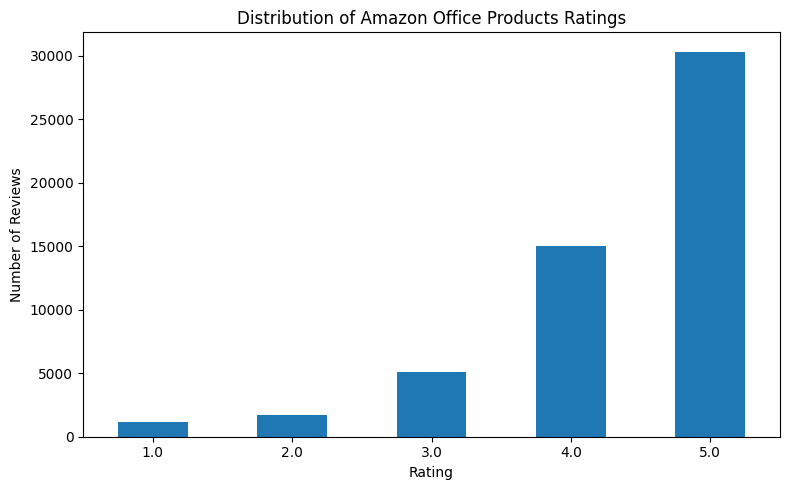

In [6]:
# Figure 1: Rating distribution
plt.figure(figsize=(8, 5))
rating_counts.plot(kind="bar")
plt.title("Distribution of Amazon Office Products Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


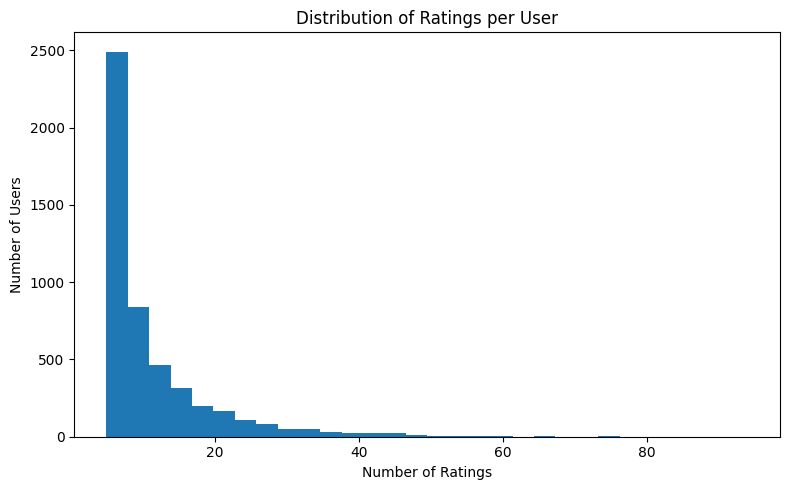

count    4905.000000
mean       10.857900
std         8.741133
min         5.000000
25%         5.000000
50%         7.000000
75%        13.000000
max        94.000000
dtype: float64


In [7]:
# Figure 2: Ratings per user
ratings_per_user = data.groupby("user_id").size()

plt.figure(figsize=(8, 5))
plt.hist(ratings_per_user, bins=30)
plt.title("Distribution of Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()

print(ratings_per_user.describe())


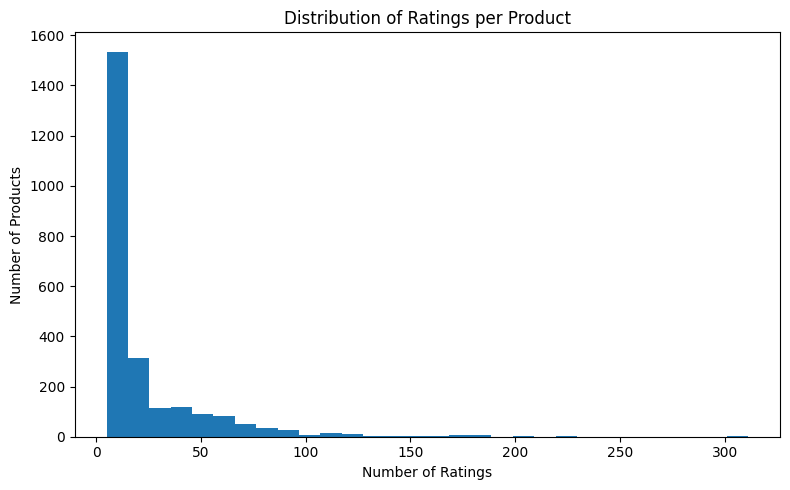

count    2420.000000
mean       22.007438
std        27.552272
min         5.000000
25%         6.000000
50%        10.000000
75%        23.000000
max       311.000000
dtype: float64


In [8]:
# Figure 3: Ratings per product
ratings_per_item = data.groupby("item_id").size()

plt.figure(figsize=(8, 5))
plt.hist(ratings_per_item, bins=30)
plt.title("Distribution of Ratings per Product")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

print(ratings_per_item.describe())


In [9]:
# Most frequently rated products (ASINs)
top_products = (
    data.groupby("item_id")
        .agg(number_of_ratings=("rating", "size"),
             average_rating=("rating", "mean"))
        .sort_values("number_of_ratings", ascending=False)
        .head(10)
)
display(top_products)


,number_of_ratings,average_rating
item_id,,
B0010T3QT2,311,4.218650
B0039N7ELS,227,4.533040
B0027CTFBO,205,4.624390
B0039N3QFQ,186,3.994624
B000MFHX3U,185,4.324324
B002K9M6OW,185,4.610811
B002K9GOPE,182,4.769231
B0039N3QO2,182,4.225275
B002K9IHJK,180,4.483333


### EDA Interpretation

After cleaning, the dataset contains **53,258 ratings from 4,905 users on 2,420 products**. The resulting user-product matrix has 11,870,100 possible interactions, but only 53,258 are observed, giving a density of approximately **0.4487%** and sparsity of approximately **99.5513%**. The 5-core construction guarantees at least five reviews per retained user and product, but the matrix remains highly sparse.

The mean rating is **4.3460** and the median is **5.0**, showing a strong positive-rating bias. Ratings of 5 account for 30,327 reviews (**56.94%**) and ratings of 4 account for 15,015 (**28.19%**); together, ratings of 4 or 5 make up approximately **85.13%** of the dataset. This imbalance can make rating prediction appear accurate while making it harder to distinguish among products that users already rate positively.

User activity is uneven: users have a median of **7 ratings** and an average of approximately **10.86**, while products have a median of **10 ratings** and an average of approximately **22.01**. The histograms and top-product table therefore show that some users and products contribute substantially more observations than others. Collaborative filtering can learn more reliable latent factors for these frequently observed entities, but recommendations may favor popular products and be less reliable for users or products near the five-review minimum.

These findings motivate evaluating both predictive error and recommendation quality. RMSE and MAE summarize held-out rating accuracy, while the Top-N output should be checked separately for coverage, popularity concentration, and usefulness.

## 6. Collaborative Filtering Model Development — Maaz

The cleaned data are converted to a Surprise dataset. A 75/25 train-test split is used. SVD learns latent user and product factors from historical ratings and predicts ratings for held-out interactions.


In [10]:
reader = Reader(rating_scale=(1, 5))
data_surprise = Dataset.load_from_df(
    data[["user_id", "item_id", "rating"]],
    reader
)

trainset, testset = train_test_split(
    data_surprise,
    test_size=0.25,
    random_state=RANDOM_STATE
)

print("Training ratings:", trainset.n_ratings)
print("Testing ratings:", len(testset))


Training ratings: 39943
Testing ratings: 13315


In [11]:
svd_model = SVD(random_state=RANDOM_STATE)
svd_model.fit(trainset)

predictions = svd_model.test(testset)

rmse_value = accuracy.rmse(predictions, verbose=True)
mae_value = accuracy.mae(predictions, verbose=True)

print(f"\nInitial SVD RMSE: {rmse_value:.4f}")
print(f"Initial SVD MAE:  {mae_value:.4f}")


RMSE: 0.8508
MAE:  0.6329

Initial SVD RMSE: 0.8508
Initial SVD MAE:  0.6329


## 7. Evaluation and Interpretation — Raja + Maaz

**RMSE** measures the square-root of the average squared difference between actual and predicted ratings. Lower RMSE indicates better predictive accuracy.

Interpret the exact value printed above in the context of a 1–5 rating scale. Also note that rating prediction accuracy alone does not measure recommendation diversity, novelty, fairness, or business usefulness.


In [12]:
# Preview actual vs. predicted ratings
prediction_df = pd.DataFrame(
    [(p.uid, p.iid, p.r_ui, p.est) for p in predictions],
    columns=["user_id", "item_id", "actual_rating", "predicted_rating"]
)
prediction_df["absolute_error"] = (
    prediction_df["actual_rating"] - prediction_df["predicted_rating"]
).abs()

display(prediction_df.head(10))
display(prediction_df["absolute_error"].describe())


,user_id,item_id,actual_rating,predicted_rating,absolute_error
0,A2HMF8ZR67BNZS,B0006OF5MI,5.0,4.607234,0.392766
1,A3TPNC3TKGCCEI,B00ASHH602,5.0,4.741657,0.258343
2,A2AMTEB5UZEOXE,B005K8AUWA,1.0,4.147606,3.147606
3,ATYUQROTHLNYV,B003FHBPRM,4.0,4.325982,0.325982
4,AUAX1QWUCYKSX,B000A0OFXS,4.0,4.233118,0.233118
5,AHUT55E980RDR,B00B80SOW2,5.0,4.860294,0.139706
6,AWAB7PKBO3BBT,B008HSIVVC,3.0,3.996811,0.996811
7,A3H11VW0L01A1T,B00347A8GM,4.0,4.672976,0.672976
8,A26EQ8U96JA92T,B000CCXXQY,4.0,4.846740,0.846740
9,A1F958T2GSWCEK,B004GBGRYM,5.0,4.204550,0.795450


,absolute_error
count,13315.000000
mean,0.632895
std,0.568680
min,0.000000
25%,0.284428
50%,0.496991
75%,0.785647
max,3.976899


## 8. Optional Extension: Hyperparameter Tuning and Top-N Recommendations — Maaz

This section goes beyond the minimum Deliverable 1 requirements and prepares the group for later project stages.


In [13]:
# Optional: Grid-search SVD hyperparameters.
# Keep RUN_TUNING=False for the faster reproducible default configuration.
RUN_TUNING = False

param_grid = {
    "n_factors": [50, 100],
    "n_epochs": [20, 40],
    "lr_all": [0.002, 0.005],
    "reg_all": [0.02, 0.05],
    "random_state": [RANDOM_STATE]
}

default_params = {
    "n_factors": 100,
    "n_epochs": 20,
    "lr_all": 0.005,
    "reg_all": 0.02,
    "random_state": RANDOM_STATE
}

if RUN_TUNING:
    grid_search = GridSearchCV(
        SVD,
        param_grid,
        measures=["rmse"],
        cv=3,
        n_jobs=-1
    )
    grid_search.fit(data_surprise)
    best_params = grid_search.best_params["rmse"]
    print("Best RMSE:", grid_search.best_score["rmse"])
    print("Best parameters:", best_params)
else:
    best_params = default_params.copy()
    print("Grid search skipped; using reproducible default parameters:", best_params)

assert best_params["random_state"] == RANDOM_STATE


Grid search skipped; using reproducible default parameters: {'n_factors': 100, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.02, 'random_state': 42}


In [14]:
# Train a final model using all available ratings and the selected parameters.
full_trainset = data_surprise.build_full_trainset()

final_model = SVD(**best_params)
final_model.fit(full_trainset)

print("Final model trained on the complete dataset.")


Final model trained on the complete dataset.


In [15]:
def get_top_n_recommendations(model, raw_user_id, n=10):
    all_items = set(data["item_id"].unique())
    rated_items = set(
        data.loc[data["user_id"] == str(raw_user_id), "item_id"].tolist()
    )

    predictions_for_user = []
    for item_id in sorted(all_items - rated_items):
        estimated_rating = model.predict(str(raw_user_id), str(item_id)).est
        predictions_for_user.append((item_id, estimated_rating))

    predictions_for_user.sort(key=lambda item: (-item[1], item[0]))
    return predictions_for_user[:n]


def get_top_n_for_all_users(model, n=10):
    return {
        user_id: get_top_n_recommendations(model, user_id, n=n)
        for user_id in sorted(data["user_id"].unique())
    }


# Generate Top-N recommendations for every user, excluding products they already rated.
TOP_N = 10
top_n_by_user = get_top_n_for_all_users(final_model, n=TOP_N)
recommendations_df = pd.DataFrame(
    [
        (user_id, rank, item_id, predicted_rating)
        for user_id, recommendations in top_n_by_user.items()
        for rank, (item_id, predicted_rating) in enumerate(recommendations, start=1)
    ],
    columns=["user_id", "rank", "item_id", "predicted_rating"]
)

assert len(top_n_by_user) == data["user_id"].nunique()
assert not recommendations_df.duplicated(["user_id", "item_id"]).any()
assert recommendations_df["rank"].between(1, TOP_N).all()

print(f"Users with recommendations: {len(top_n_by_user):,}")
print(f"Recommendation rows generated: {len(recommendations_df):,}")
print(f"Expected maximum rows: {len(top_n_by_user) * TOP_N:,}")
display(recommendations_df.head(20))


Users with recommendations: 4,905
Recommendation rows generated: 49,050
Expected maximum rows: 49,050


,user_id,rank,item_id,predicted_rating
0,A00473363TJ8YSZ3YAGG9,1,B000J05GKA,4.736978
1,A00473363TJ8YSZ3YAGG9,2,B00IL7BJMM,4.732071
2,A00473363TJ8YSZ3YAGG9,3,B00HVUYKN0,4.711609
3,A00473363TJ8YSZ3YAGG9,4,B00006IEGO,4.674996
4,A00473363TJ8YSZ3YAGG9,5,B002K9GOPE,4.657643
5,A00473363TJ8YSZ3YAGG9,6,B000MALXVS,4.649603
6,A00473363TJ8YSZ3YAGG9,7,B00006IEC6,4.633628
7,A00473363TJ8YSZ3YAGG9,8,B002M8EY82,4.626709
8,A00473363TJ8YSZ3YAGG9,9,B000H10YZS,4.614553
9,A00473363TJ8YSZ3YAGG9,10,B001S9HWKS,4.613597


## 9. Ethical Considerations and Limitations — Raja

Key considerations:
- **Privacy:** Interaction histories can reveal user preferences and behavior; identifiers should remain anonymized and access controlled.
- **Bias and popularity effects:** Products with more interactions can receive more visibility, while less-reviewed products may be disadvantaged.
- **Transparency:** Users should understand that recommendations are algorithmically generated from historical interactions.
- **Cold start:** Collaborative filtering struggles with new users and new products lacking interaction histories.
- **Historical data:** The selected Amazon review snapshot spans historical review activity and should not be interpreted as a current representation of Amazon's catalog or current customer behavior.
- **Evaluation scope:** RMSE evaluates rating-prediction error but not ranking quality, novelty, diversity, or fairness.


## 10. Final Reproducibility Summary

Run this final cell and copy the reported values into the final written report before submission.


In [16]:
print("=" * 70)
print("FINAL PROJECT SUMMARY")
print("=" * 70)
print(f"Rows after cleaning: {len(data):,}")
print(f"Unique users:        {data['user_id'].nunique():,}")
print(f"Unique products:     {data['item_id'].nunique():,}")
print(f"Mean rating:         {data['rating'].mean():.4f}")
print(f"Matrix sparsity:     {(1 - len(data)/(data['user_id'].nunique()*data['item_id'].nunique())):.4%}")
print(f"Initial SVD RMSE:    {rmse_value:.4f}")
print(f"Initial SVD MAE:     {mae_value:.4f}")
print("=" * 70)


FINAL PROJECT SUMMARY
Rows after cleaning: 53,258
Unique users:        4,905
Unique products:     2,420
Mean rating:         4.3460
Matrix sparsity:     99.5513%
Initial SVD RMSE:    0.8508
Initial SVD MAE:     0.6329


## References

- Koren, Y., Bell, R., & Volinsky, C. (2009). Matrix factorization techniques for recommender systems. *Computer, 42*(8), 30–37. https://doi.org/10.1109/MC.2009.263
- Linden, G., Smith, B., & York, J. (2003). Amazon.com recommendations: Item-to-item collaborative filtering. *IEEE Internet Computing, 7*(1), 76–80. https://doi.org/10.1109/MIC.2003.1167344
- McAuley, J., Pandey, R., & Leskovec, J. (2015). Inferring networks of substitutable and complementary products. *Proceedings of the 21st ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 785–794.
- McAuley, J., Targett, C., Shi, Q., & van den Hengel, A. (2015). Image-based recommendations on styles and substitutes. *Proceedings of the 38th International ACM SIGIR Conference on Research and Development in Information Retrieval*, 43–52.
- Milano, S., Taddeo, M., & Floridi, L. (2020). Recommender systems and their ethical challenges. *AI & Society, 35*, 957–967. https://doi.org/10.1007/s00146-020-00950-y
- Adomavicius, G., & Tuzhilin, A. (2005). Toward the next generation of recommender systems: A survey of the state-of-the-art and possible extensions. *IEEE Transactions on Knowledge and Data Engineering, 17*(6), 734–749. https://doi.org/10.1109/TKDE.2005.99
